In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [46]:
df = pd.read_csv("../data/processed/cleaned_samsung_phones.csv")

In [47]:
df.head()

,model_name,series,launch_year,price_inr,ram_gb,storage_gb,processor_score,main_camera_mp,ultrawide_mp,telephoto_mp,front_camera_mp,ois,battery_mah,charging_w,refresh_rate_hz,screen_size_inch,weight_g,ai_features,waterproof,target_segment
0,Galaxy A06,A,2025,10999,4,64,3.5,50,2,0,8,No,5000,25,60,6.7,189,No,No,budget
1,Galaxy A15 5G,A,2024,17999,6,128,5.0,50,2,0,13,No,5000,25,90,6.5,200,No,No,budget
2,Galaxy A16 5G,A,2025,19999,8,128,5.5,48,8,0,13,No,5000,25,90,6.7,198,Basic AI,No,budget
3,Galaxy A25 5G,A,2024,24999,8,128,6.2,48,8,0,13,No,5000,25,120,6.5,197,Basic AI,No,budget
4,Galaxy A26 5G,A,2025,27999,8,256,6.5,64,8,0,13,Yes,5000,25,120,6.7,197,Basic AI,Yes,photography


In [48]:
df.shape

(30, 20)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   model_name        30 non-null     str    
 1   series            30 non-null     str    
 2   launch_year       30 non-null     int64  
 3   price_inr         30 non-null     int64  
 4   ram_gb            30 non-null     int64  
 5   storage_gb        30 non-null     int64  
 6   processor_score   30 non-null     float64
 7   main_camera_mp    30 non-null     int64  
 8   ultrawide_mp      30 non-null     int64  
 9   telephoto_mp      30 non-null     int64  
 10  front_camera_mp   30 non-null     int64  
 11  ois               30 non-null     str    
 12  battery_mah       30 non-null     int64  
 13  charging_w        30 non-null     int64  
 14  refresh_rate_hz   30 non-null     int64  
 15  screen_size_inch  30 non-null     float64
 16  weight_g          30 non-null     int64  
 17  ai_feature

Price Distribution

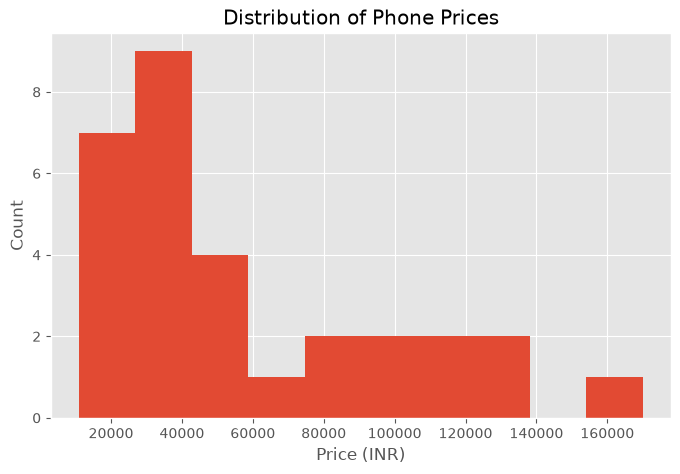

In [50]:
plt.figure(figsize=(8,5))

plt.hist(df["price_inr"], bins=10)

plt.title("Distribution of Phone Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")

plt.show()

RAM DISTRIBUTION

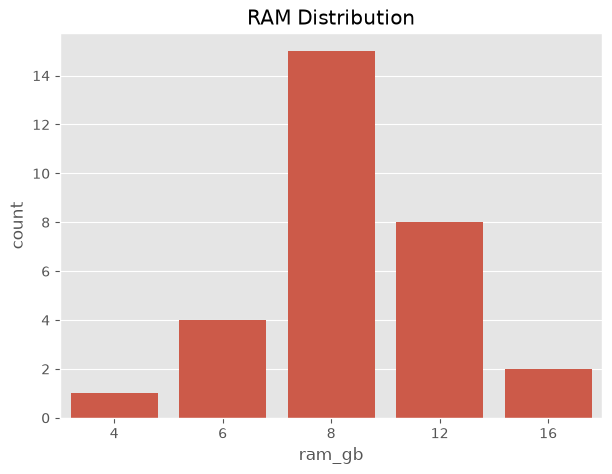

In [51]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="ram_gb")

plt.title("RAM Distribution")

plt.show()

Storage Distribution

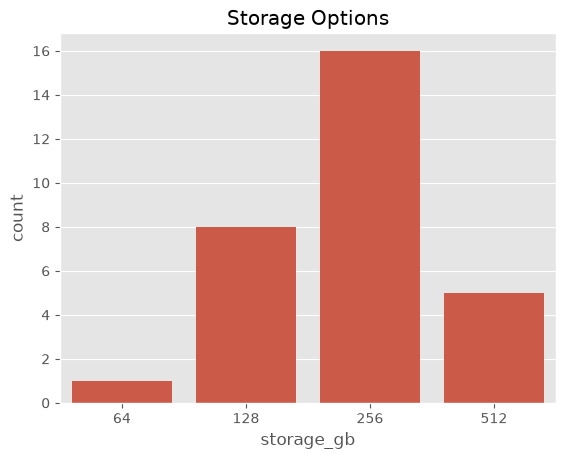

In [52]:
sns.countplot(data=df, x="storage_gb")

plt.title("Storage Options")

plt.show()

Target Segment


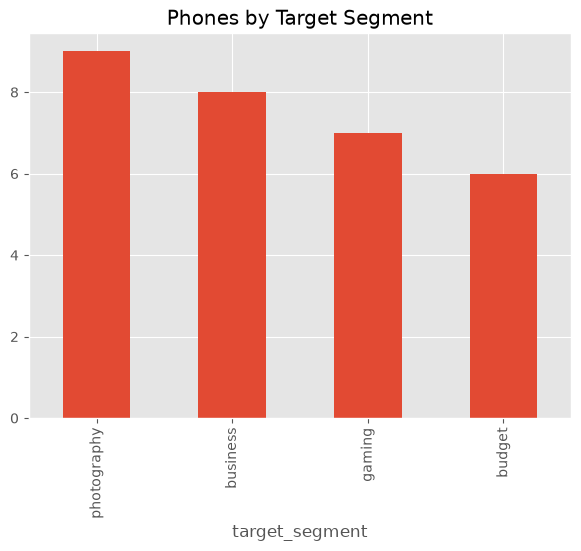

In [53]:
df["target_segment"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Phones by Target Segment")

plt.show()

Average Price by Series

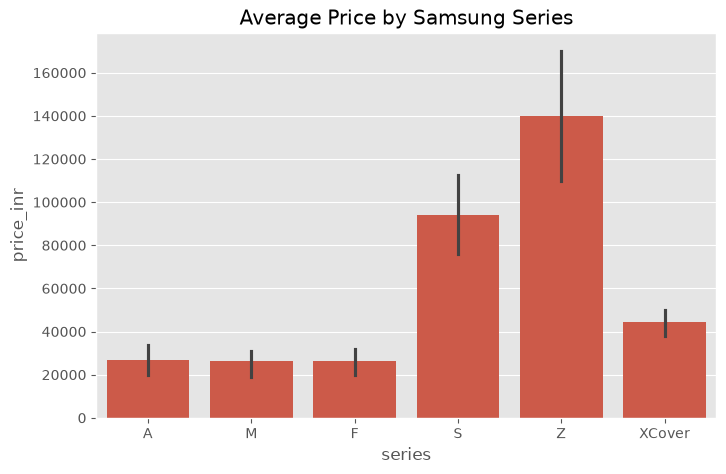

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="series",
    y="price_inr",
    estimator="mean"
)

plt.title("Average Price by Samsung Series")

plt.show()

Battery vs Price

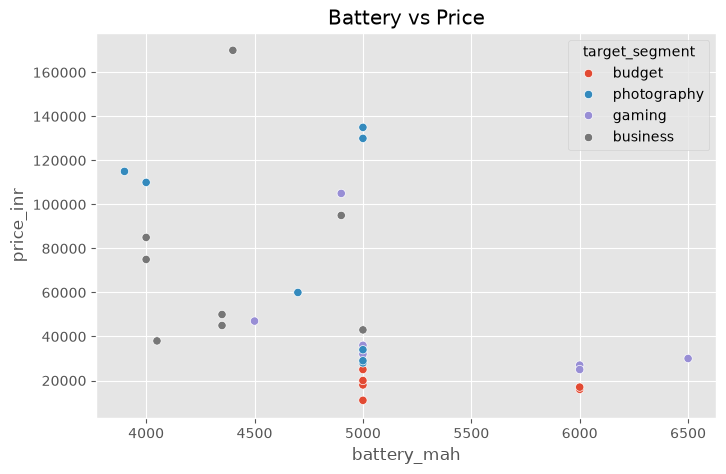

In [55]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="battery_mah",
    y="price_inr",
    hue="target_segment"
)

plt.title("Battery vs Price")

plt.show()

Processor Score vs Price

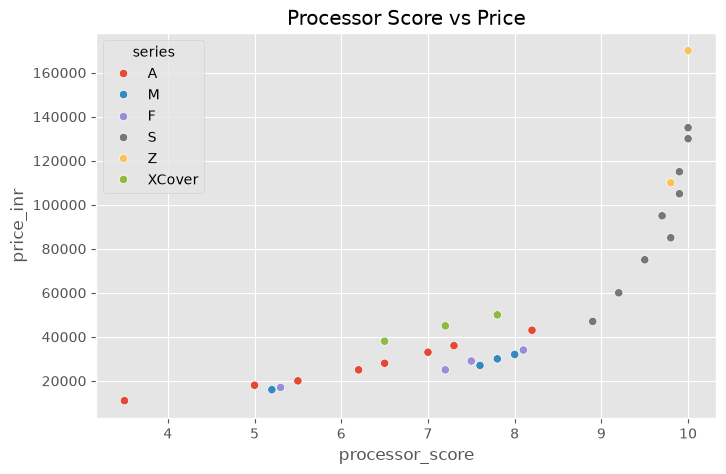

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="processor_score",
    y="price_inr",
    hue="series"
)

plt.title("Processor Score vs Price")

plt.show()

Main Camera vs Price

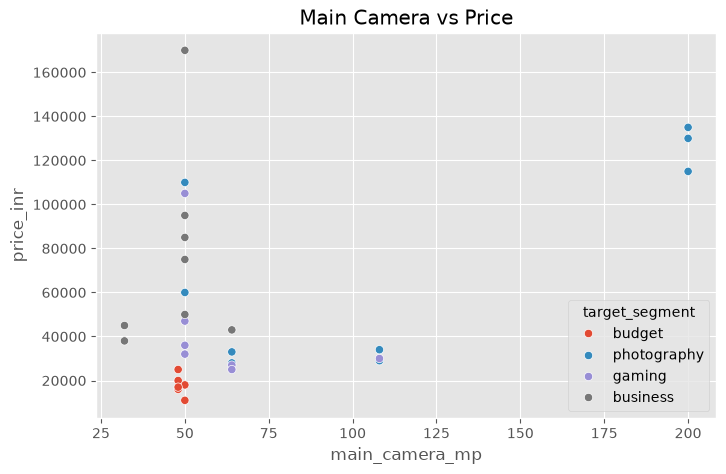

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="main_camera_mp",
    y="price_inr",
    hue="target_segment"
)

plt.title("Main Camera vs Price")

plt.show()

Correlation Heatmap

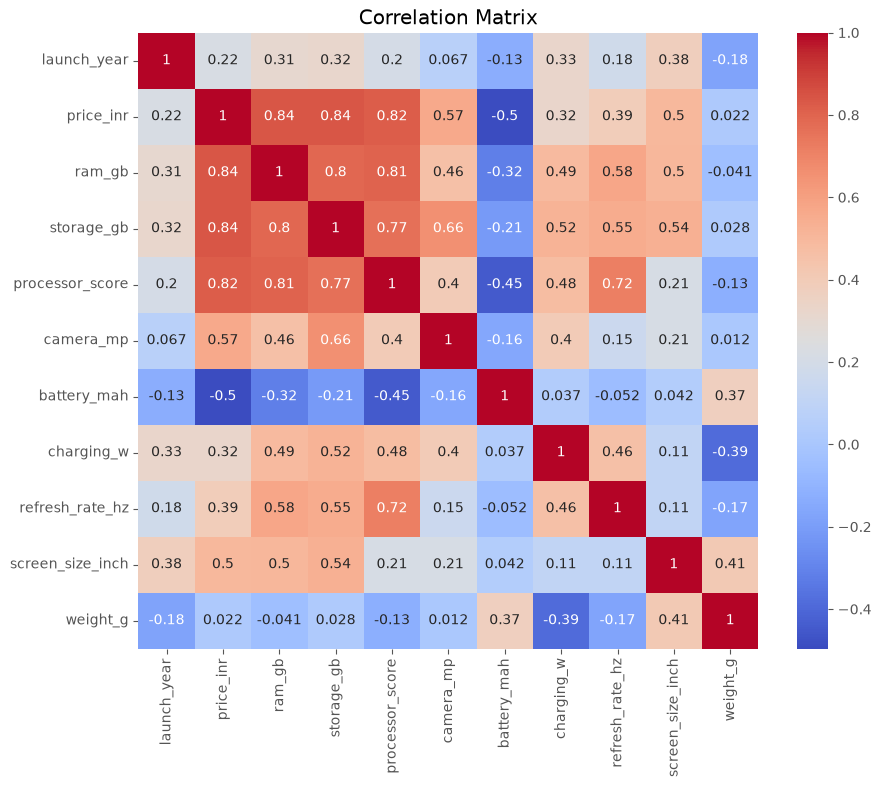

In [ ]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

AI Features

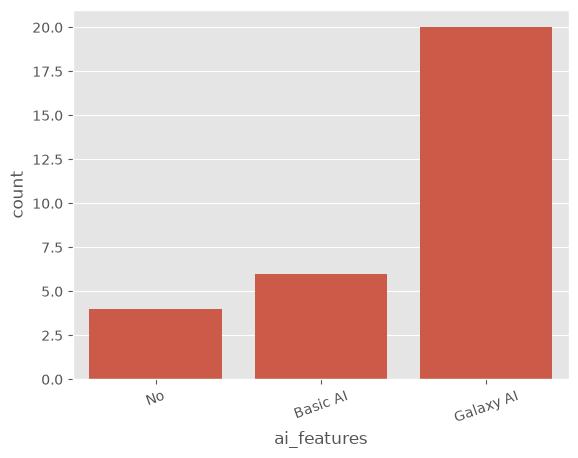

In [ ]:
sns.countplot(
    data=df,
    x="ai_features"
)

plt.xticks(rotation=20)

plt.show()

Waterproof Phones

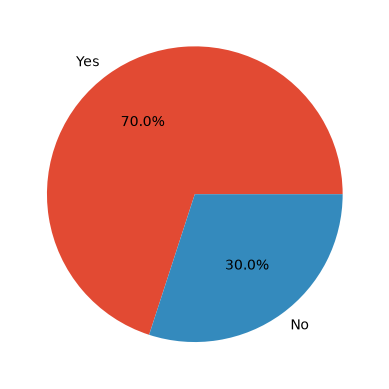

In [ ]:
df["waterproof"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Refresh Rate

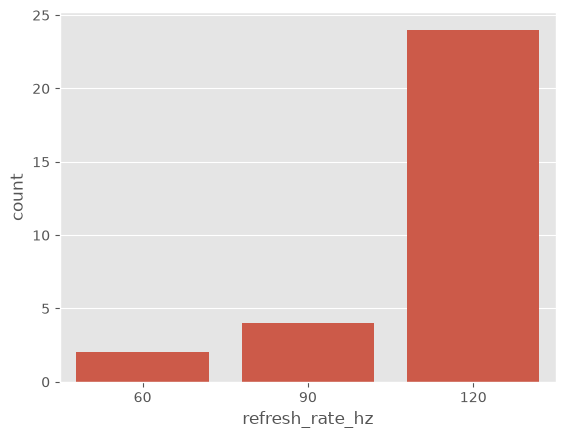

In [ ]:
sns.countplot(
    data=df,
    x="refresh_rate_hz"
)

plt.show()

1. Flagship phones have the highest processor scores and prices.
2. Gaming phones generally offer larger batteries and higher refresh rates.
3. Photography phones tend to include Galaxy AI features.
4. Budget phones are clustered below ₹30,000.
5. Battery capacity alone does not determine price.
6. Processor score has a stronger relationship with price than RAM.

Average Specifications by Segment

In [60]:
df.groupby("target_segment")[
    [
        "price_inr",
        "processor_score",
        "battery_mah",
        "main_camera_mp"
    ]
].mean()

,price_inr,processor_score,battery_mah,main_camera_mp
target_segment,,,,
budget,17832.333333,5.116667,5333.333333,48.666667
business,75124.000000,8.587500,4381.250000,47.250000
gaming,43141.857143,8.100000,5414.285714,62.285714
photography,74887.888889,8.666667,4733.333333,116.000000
